In [1]:
import models.model as modelclass
from configs import config
import torch
import torch.nn as nn
import utils.log as log
import json

In [2]:
cfgs = config.Configurations('./configs/LSFB/conv1d/vanilla-medium-deep-daug.yaml')

In [3]:
logger = log.make_logger('./logs/testing/', "test", None)
logger.info("Run name : {run_name}".format(run_name='test'))
for k, v in cfgs.super_cfgs.items():
    logger.info("cfgs." + k + " =")
    logger.info(json.dumps(vars(v), indent=2))

[INFO] 2024-04-13 14:55:55 > Run name : test
[INFO] 2024-04-13 14:55:55 > cfgs.DATA =
[INFO] 2024-04-13 14:55:55 > {
  "name": "LSFB",
  "input_size": [
    32,
    99,
    3
  ],
  "num_classes": 610,
  "min_samples": 20,
  "max_len": 32,
  "oversample": true,
  "poses": [
    [
      "pose",
      "all"
    ],
    [
      "right_hand",
      "all"
    ],
    [
      "left_hand",
      "all"
    ],
    [
      "face",
      [
        61,
        39,
        0,
        269,
        291,
        405,
        17,
        181,
        33,
        159,
        133,
        145,
        46,
        52,
        65,
        55,
        263,
        386,
        362,
        374,
        276,
        282,
        295,
        285
      ]
    ]
  ],
  "num_keypoints": 99,
  "flip_p": 0.5,
  "scale": 0.05,
  "random_crop": false,
  "drop_frame": 0.2,
  "drop_keypoint": 0.2,
  "block_size": 9,
  "rot": 5
}
[INFO] 2024-04-13 14:55:55 > cfgs.MODEL =
[INFO] 2024-04-13 14:55:55 > {
  "backbone": "con

In [4]:
rank = torch.cuda.current_device()
model = modelclass.load_classifier(DATA=cfgs.DATA,
                                MODEL=cfgs.MODEL,
                                MODULES=cfgs.MODULES,
                                RUN=cfgs.RUN,
                                device=rank,
                                logger=logger)

[INFO] 2024-04-13 14:55:55 > Build the model.
[INFO] 2024-04-13 14:55:55 > Modules are located on './src/models.conv1d'.


[INFO] 2024-04-13 14:55:56 > Number of parameters: 337574
[INFO] 2024-04-13 14:55:56 > Classifier(
  (blocks): ModuleList(
    (0): ModuleList(
      (0): Block(
        (conv1d0): Conv1DBlock(
          (in_linear): Linear(in_features=32, out_features=64, bias=True)
          (conv1d): dwconv1d(
            (pad): ConstantPad1d(padding=(16, 0), value=0)
            (conv): Conv1d(64, 64, kernel_size=(17,), stride=(1,), padding=valid, groups=64)
          )
          (eca): eca(
            (avg_pool): AdaptiveAvgPool2d(output_size=1)
            (conv): Conv1d(1, 1, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
            (sigmoid): Sigmoid()
          )
          (bn): BatchNorm1d(64, eps=0.0001, momentum=0.1, affine=True, track_running_stats=True)
          (out_linear): Linear(in_features=64, out_features=32, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
          (drop_path): StochasticDepth(p=0.0, mode=batch)
          (activation): GELU(approximate='n

In [5]:
from torchinfo import summary

batch_size = 32
summary(model, input_size=(batch_size, 32,99*3), depth=1)

Layer (type:depth-idx)                                  Output Shape              Param #
Classifier                                              [32, 610]                 64
├─Linear: 1-1                                           [32, 32, 32]              9,504
├─ModuleList: 1-2                                       --                        299,556
├─Linear: 1-3                                           [32, 32, 128]             8,320
├─Dropout: 1-4                                          [32, 32, 128]             --
├─Linear: 1-5                                           [32, 610]                 20,130
Total params: 538,617
Trainable params: 538,617
Non-trainable params: 0
Total mult-adds (M): 33.80
Input size (MB): 1.22
Forward/backward pass size (MB): 50.23
Params size (MB): 1.08
Estimated Total Size (MB): 52.53

In [6]:
import models.conv1d as conv1d

conv1d.Classifier(input_size=cfgs.DATA.input_size,
                                   conv_dim=cfgs.MODEL.conv_dim,
                                   apply_attn=cfgs.MODEL.apply_attn,
                                   expand_ratio=cfgs.MODEL.expand_ratio,
                                   nheads=cfgs.MODEL.nheads,
                                   dropout=cfgs.MODEL.dropout,
                                   num_classes=cfgs.DATA.num_classes,
                                   init_weights=cfgs.MODEL.init,
                                   depth=cfgs.MODEL.depth,
                                   mixed_precision=cfgs.RUN.mixed_precision,
                                   MODULES=cfgs.MODULES,
                                   MODEL=cfgs.MODEL,
                                   embed_size=cfgs.MODEL.embed_size,
                                   drop_path=cfgs.MODEL.drop_path).to(rank)

Classifier(
  (blocks): ModuleList(
    (0): ModuleList(
      (0): Block(
        (conv1d0): Conv1DBlock(
          (in_linear): Linear(in_features=32, out_features=64, bias=True)
          (conv1d): dwconv1d(
            (pad): ConstantPad1d(padding=(16, 0), value=0)
            (conv): Conv1d(64, 64, kernel_size=(17,), stride=(1,), padding=valid, groups=64)
          )
          (eca): eca(
            (avg_pool): AdaptiveAvgPool2d(output_size=1)
            (conv): Conv1d(1, 1, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
            (sigmoid): Sigmoid()
          )
          (bn): BatchNorm1d(64, eps=0.0001, momentum=0.1, affine=True, track_running_stats=True)
          (out_linear): Linear(in_features=64, out_features=32, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
          (drop_path): StochasticDepth(p=0.0, mode=batch)
          (activation): GELU(approximate='none')
        )
        (conv1d1): Conv1DBlock(
          (in_linear): Linear(in_featur

In [9]:
in_dims = [cfgs.MODEL.conv_dim]*cfgs.MODEL.depth
for index in range(len(in_dims)):
    print(in_dims[index])

64
64
64
64


In [10]:
input_tensor = torch.randn(32, cfgs.DATA.input_size[0], cfgs.DATA.input_size[1],cfgs.DATA.input_size[2]).to(rank)
torch.transpose(input_tensor, 2, 3).shape

torch.Size([32, 32, 3, 99])

In [11]:
input_tensor.shape

torch.Size([32, 32, 99, 3])

In [12]:
# Generate a random input tensor
input_tensor = torch.randn(32, cfgs.DATA.input_size[0], cfgs.DATA.input_size[1]*cfgs.DATA.input_size[2]).to(rank)

# Pass the input tensor through the model
output_tensor = model(input_tensor)

# Print the output tensor
print(output_tensor)

tensor([[-0.0053,  0.0185, -0.0016,  ..., -0.0098,  0.0121, -0.0113],
        [-0.0058, -0.0127, -0.0016,  ..., -0.0200,  0.0171,  0.0082],
        [-0.0004,  0.0296, -0.0167,  ..., -0.0142,  0.0057,  0.0205],
        ...,
        [-0.0024,  0.0135, -0.0226,  ...,  0.0021, -0.0015,  0.0274],
        [-0.0187,  0.0316, -0.0045,  ..., -0.0009,  0.0231, -0.0036],
        [ 0.0112,  0.0074, -0.0055,  ..., -0.0040,  0.0233,  0.0133]],
       device='cuda:0', grad_fn=<AddmmBackward0>)


In [13]:
from data.data_util import Dataset_, train_val_dataset, OversamplingWrapper
import utils.misc as misc

data_name = "LSFB"
data_dir = "/mnt/sda2/datasets/isolated-cont-sl/LSFB/"
poses = [["pose","all"],["right_hand","all"],["left_hand","all"], ["face",[61,39,0,269,291,405,17,181,33,159,133,145,46,52,65,55,263,386,362,374,276,282,295,285]]]
dset_used = 1
seed = 42
oversample = True

In [14]:
print("Load {name} train dataset.".format(name=data_name))
train_dataset = Dataset_(data_dir=data_dir,
                            train=True,
                            load_data_in_memory=False,
                            poses=poses,
                            max_len=32,
                            min_samples=20,
                            drop_frame=0.5,
                            drop_keypoint=0.5,
                            block_size=60,
                            flip_p=0.5,
                            scale=0.5,
                            rot=5)
print("Train dataset size: {dataset_size}".format(dataset_size=len(train_dataset)))


Load LSFB train dataset.
Train dataset size: 52350


In [15]:
torch.reshape(train_dataset[0][0], (1,train_dataset[0][0].shape[0],train_dataset[0][0].shape[1])).shape

torch.Size([1, 32, 297])

In [16]:
with torch.autocast("cuda"):
    # Pass the input tensor through the model
    output_tensor = model(torch.reshape(train_dataset[0][0], (1,train_dataset[0][0].shape[0],train_dataset[0][0].shape[1])).to(rank))

# Print the output tensor
print(output_tensor)

tensor([[-0.0341,  0.0323,  0.0033,  0.0093,  0.0264,  0.0093,  0.0058, -0.0020,
          0.0368, -0.0065,  0.0166,  0.0160, -0.0090, -0.0326,  0.0022,  0.0038,
          0.0027,  0.0223,  0.0162, -0.0094,  0.0358,  0.0135,  0.0039, -0.0015,
         -0.0278,  0.0184,  0.0054, -0.0117,  0.0017, -0.0172, -0.0203, -0.0224,
         -0.0021, -0.0160,  0.0065,  0.0025,  0.0204, -0.0060, -0.0141, -0.0022,
         -0.0105,  0.0030, -0.0177,  0.0088, -0.0010, -0.0432,  0.0211, -0.0083,
          0.0032, -0.0242, -0.0365,  0.0089, -0.0387,  0.0254, -0.0081, -0.0092,
         -0.0228, -0.0312, -0.0223, -0.0221, -0.0207, -0.0131,  0.0166, -0.0101,
          0.0166, -0.0127,  0.0080,  0.0034,  0.0112, -0.0140, -0.0211,  0.0028,
          0.0101, -0.0134,  0.0184, -0.0038, -0.0210, -0.0132, -0.0104,  0.0185,
         -0.0196, -0.0166, -0.0017,  0.0414,  0.0323, -0.0055, -0.0013,  0.0117,
          0.0075,  0.0237,  0.0063,  0.0023,  0.0094, -0.0309,  0.0033, -0.0027,
          0.0099, -0.0177,  

In [18]:
import torch.utils.benchmark as benchmark

input = train_dataset[0]
values = torch.reshape(input[0], (1,input[0].shape[0],input[0].shape[1])).to(rank)
labels = torch.tensor([input[1]]).to(rank)

def stepmodel(input):
    with torch.autocast("cuda"):
        # Pass the input tensor through the model
        output_tensor = model(input)
    return output_tensor

t0 = benchmark.Timer(
    stmt='stepmodel(x)',
    setup='from __main__ import stepmodel',
    globals={'x': values},
    num_threads=4)

print(t0.timeit(100))

stepmodel(x)
setup: from __main__ import stepmodel
  14.16 ms
  1 measurement, 100 runs , 4 threads


In [19]:
labels

tensor([226], device='cuda:0')

In [20]:
output_tensor.shape

torch.Size([1, 610])

In [5]:
output_tensor = stepmodel(values)
ce_loss = nn.CrossEntropyLoss()

def calc_loss(output_tensor, labels):
    # Pass the input tensor through the model
    loss = ce_loss(output_tensor, labels)
    loss.backward(retain_graph=True)
    return loss

t0 = benchmark.Timer(
    stmt='calc_loss(output_tensor, labels)',
    setup='from __main__ import calc_loss',
    globals={'output_tensor': output_tensor, 'labels': labels},
    num_threads=4)

print(t0.timeit(100))

RuntimeError: 0D or 1D target tensor expected, multi-target not supported

In [19]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def accuracy(output, target, topk=(1,)):
    """Computes the precision@k for the specified values of k"""
    maxk = max(topk)
    batch_size = target.size(0)

    _, pred = output.topk(maxk, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))

    res = []
    for k in topk:
        correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
        wrong_k = batch_size - correct_k
        res.append(100 - wrong_k.mul_(100.0 / batch_size))
    return res

output_tensor = stepmodel(values)
ce_loss = nn.CrossEntropyLoss()
loss = ce_loss(output_tensor, labels)

def opp(output_tensor, labels, values):
    # calculate topk
    valid_acc1, valid_acc10 = misc.accuracy(output_tensor.data, labels, topk=(1, 10))

    valid_top1_acc, valid_top10_acc, valid_loss = misc.AverageMeter(), misc.AverageMeter(), misc.AverageMeter()
    # accumulate loss and topk
    valid_loss.update(loss.item(), values.size(0))
    valid_top1_acc.update(valid_acc1.item(), values.size(0))
    valid_top10_acc.update(valid_acc10.item(), values.size(0))

t0 = benchmark.Timer(
    stmt='opp(output_tensor, labels, values)',
    setup='from __main__ import opp',
    globals={'output_tensor': output_tensor, 'labels': labels, 'values': values},
    num_threads=4)

print(t0.timeit(100))

opp(output_tensor, labels, values)
setup: from __main__ import opp
  260.55 us
  1 measurement, 100 runs , 4 threads


In [33]:
values.shape

torch.Size([1, 32, 297])

In [6]:
import torch
import torchvision.models as models
from torch.profiler import profile, record_function, ProfilerActivity

inputs = torch.randn(8192, 32, 297).cuda()

# Use profiler to analyze execution time
with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=True) as prof:
    with record_function("model_inference"):
        with torch.autocast("cuda"):
            model(inputs)

# Print out the stats for the execution
print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=10))


STAGE:2024-04-13 14:48:59 3818726:3818726 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
STAGE:2024-04-13 14:49:22 3818726:3818726 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2024-04-13 14:49:22 3818726:3818726 ActivityProfilerController.cpp:324] Completed Stage: Post Processing


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                  cudaDeviceSynchronize        99.31%       22.126s        99.31%       22.126s       22.126s       0.000us         0.00%       0.000us       0.000us             1  
                                        model_inference         0.03%       7.525ms         0.69%     153.329ms     153.329ms       0.000us         0.00%       27.756s       27.756s             1  
         

In [8]:
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                        model_inference         0.03%       7.525ms         0.69%     153.329ms     153.329ms       0.000us         0.00%       27.756s       27.756s             1  
                     aten::scaled_dot_product_attention         0.00%      98.000us         0.28%      62.710ms      15.678ms       0.000us         0.00%       21.754s        5.438s             4  
         

In [21]:
output_tensor

tensor([[ 4.3823e-02,  2.3834e-02, -7.2632e-03, -2.1439e-03,  2.7588e-02,
         -1.0498e-02,  4.2206e-02, -1.3138e-02, -1.8646e-02,  7.7286e-03,
         -3.0182e-02,  9.7351e-03,  1.4328e-02,  7.6790e-03, -1.0689e-02,
         -8.1024e-03,  4.2343e-03,  1.0735e-02,  4.7836e-03,  2.8477e-03,
          6.5422e-03,  2.8198e-02, -4.9286e-03,  1.6846e-02,  1.2760e-03,
         -1.1864e-02, -6.1989e-03, -1.6571e-02, -5.0888e-03, -7.9193e-03,
          2.1149e-02, -3.6812e-03, -1.7761e-02,  2.4139e-02,  1.2268e-02,
         -1.2833e-02, -5.1361e-02,  5.0140e-02, -2.2369e-02, -2.2476e-02,
          5.6190e-03, -3.0289e-02,  1.0445e-02,  3.2379e-02,  2.4734e-02,
         -1.4847e-02, -3.0930e-02, -2.3026e-02,  2.3804e-02,  1.9531e-02,
          2.6199e-02,  3.1143e-02, -1.9440e-02, -2.6840e-02,  4.7493e-03,
          4.9934e-03, -1.2894e-02, -1.3466e-02,  3.9154e-02, -1.1581e-02,
         -5.5786e-02, -9.6970e-03,  3.9635e-03,  5.3368e-03, -1.1986e-02,
         -1.8759e-03, -1.4809e-02,  7.

In [22]:
output_tensor.shape

torch.Size([1, 610])

In [23]:
import torch.nn as nn
nn.CrossEntropyLoss()

CrossEntropyLoss()

In [24]:
import torch
a = torch.rand([4,16,32])
b = torch.rand([4,32,99])
a.matmul(b).shape

torch.Size([4, 16, 99])

In [25]:
model.ema_model.update_drop_path(0.2)
model.model.update_drop_path(0.2)
model

AttributeError: 'Classifier' object has no attribute 'ema_model'

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


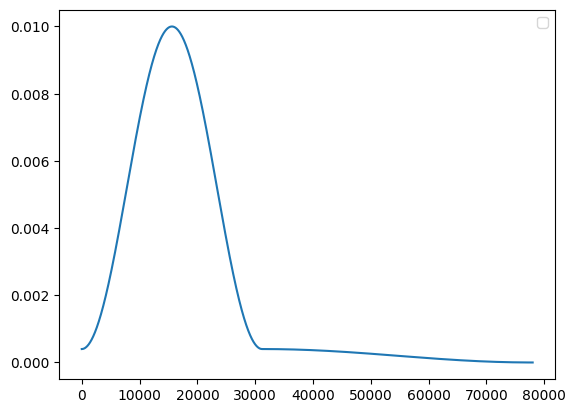

In [ ]:
import utils.optimizers as optimizers
import torch
import matplotlib.pyplot as plt
%matplotlib inline

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

EPOCHS = 200
BATCHES = int(50000/128)
steps = []
lrs = []
optimizer = torch.optim.RAdam(model.parameters(), lr=0.00001, betas=[0.001,0.999],
                                                           weight_decay=0.0,
                                                           eps=1e-6) # Wrapped optimizer
optimizer = optimizers.Lookahead(optimizer=o,k=5,alpha=0.5)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer.optimizer,three_phase=True,max_lr=0.01,pct_start=0.2,steps_per_epoch=BATCHES, epochs=EPOCHS)
for epoch in range(EPOCHS):
    for batch in range(BATCHES):
        scheduler.step()
        lrs.append(optimizer.param_groups[0]['lr'])
        steps.append(epoch * BATCHES + batch)

plt.figure()
plt.legend()
plt.plot(steps, lrs, label='OneCycle')
plt.show()

In [ ]:
import torch.utils.benchmark as benchmark
import utils.optimizers as optimizers
import torch

EPOCHS = 200
BATCHES = int(50000/128)
steps = []
lrs = []

optimizer = torch.optim.RAdam(model.parameters(), lr=0.00001, betas=[0.001,0.999],
                                                           weight_decay=0.0,
                                                           eps=1e-6) # Wrapped optimizer
optimizer = optimizers.Lookahead(optimizer=optimizer,k=5,alpha=0.5)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer.optimizer,three_phase=True,max_lr=0.01,pct_start=0.2,steps_per_epoch=BATCHES, epochs=EPOCHS)

def optstep():
    return optimizer.step()

t0 = benchmark.Timer(
    stmt='optstep()',
    setup='from __main__ import optstep',
    num_threads=4)


print(t0.timeit(100))

optstep()
setup: from __main__ import optstep
  1.39 ms
  1 measurement, 100 runs , 4 threads


/home/grios/myphyton/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:143: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


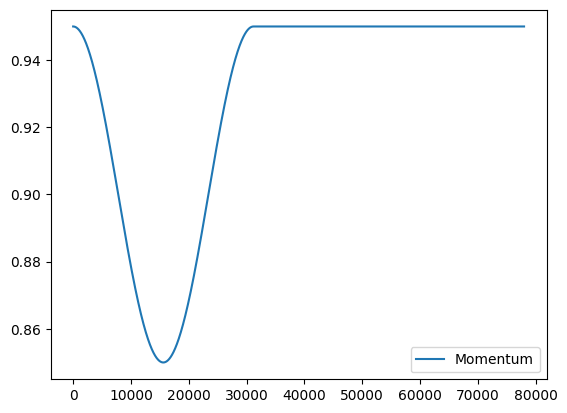

In [ ]:
import utils.optimizers as optimizers
import torch
import matplotlib.pyplot as plt
%matplotlib inline

# Function to get the momentum (beta1) from the optimizer
def get_momentum(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['betas'][0]

EPOCHS = 200
BATCHES = int(50000/128)
steps = []
momentums = []
optimizer = torch.optim.RAdam(model.parameters(), lr=0.00001, betas=[0.001,0.999],
                                                           weight_decay=0.0,
                                                           eps=1e-6) # Wrapped optimizer
optimizer = optimizers.Lookahead(optimizer=optimizer, k=5, alpha=0.5)  # Corrected 'o' to 'optimizer'
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer.optimizer, three_phase=True, max_lr=0.01, pct_start=0.2, steps_per_epoch=BATCHES, epochs=EPOCHS)

# Collecting momentum values
for epoch in range(EPOCHS):
    for batch in range(BATCHES):
        scheduler.step()
        momentums.append(get_momentum(optimizer))
        steps.append(epoch * BATCHES + batch)

# Plotting the momentum values
plt.figure()
plt.plot(steps, momentums, label='Momentum')
plt.legend()
plt.show()


In [ ]:
optimizer.param_groups[0]['lr']

4.253471299971048e-08